<a href="https://colab.research.google.com/github/melia1702/Pertemuan-kelimabelas/blob/main/PRAKTIKUM_15_4_MG_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SURVEILLANCE SYSTEMS: PEOPLE COUNTING AND TRACKING


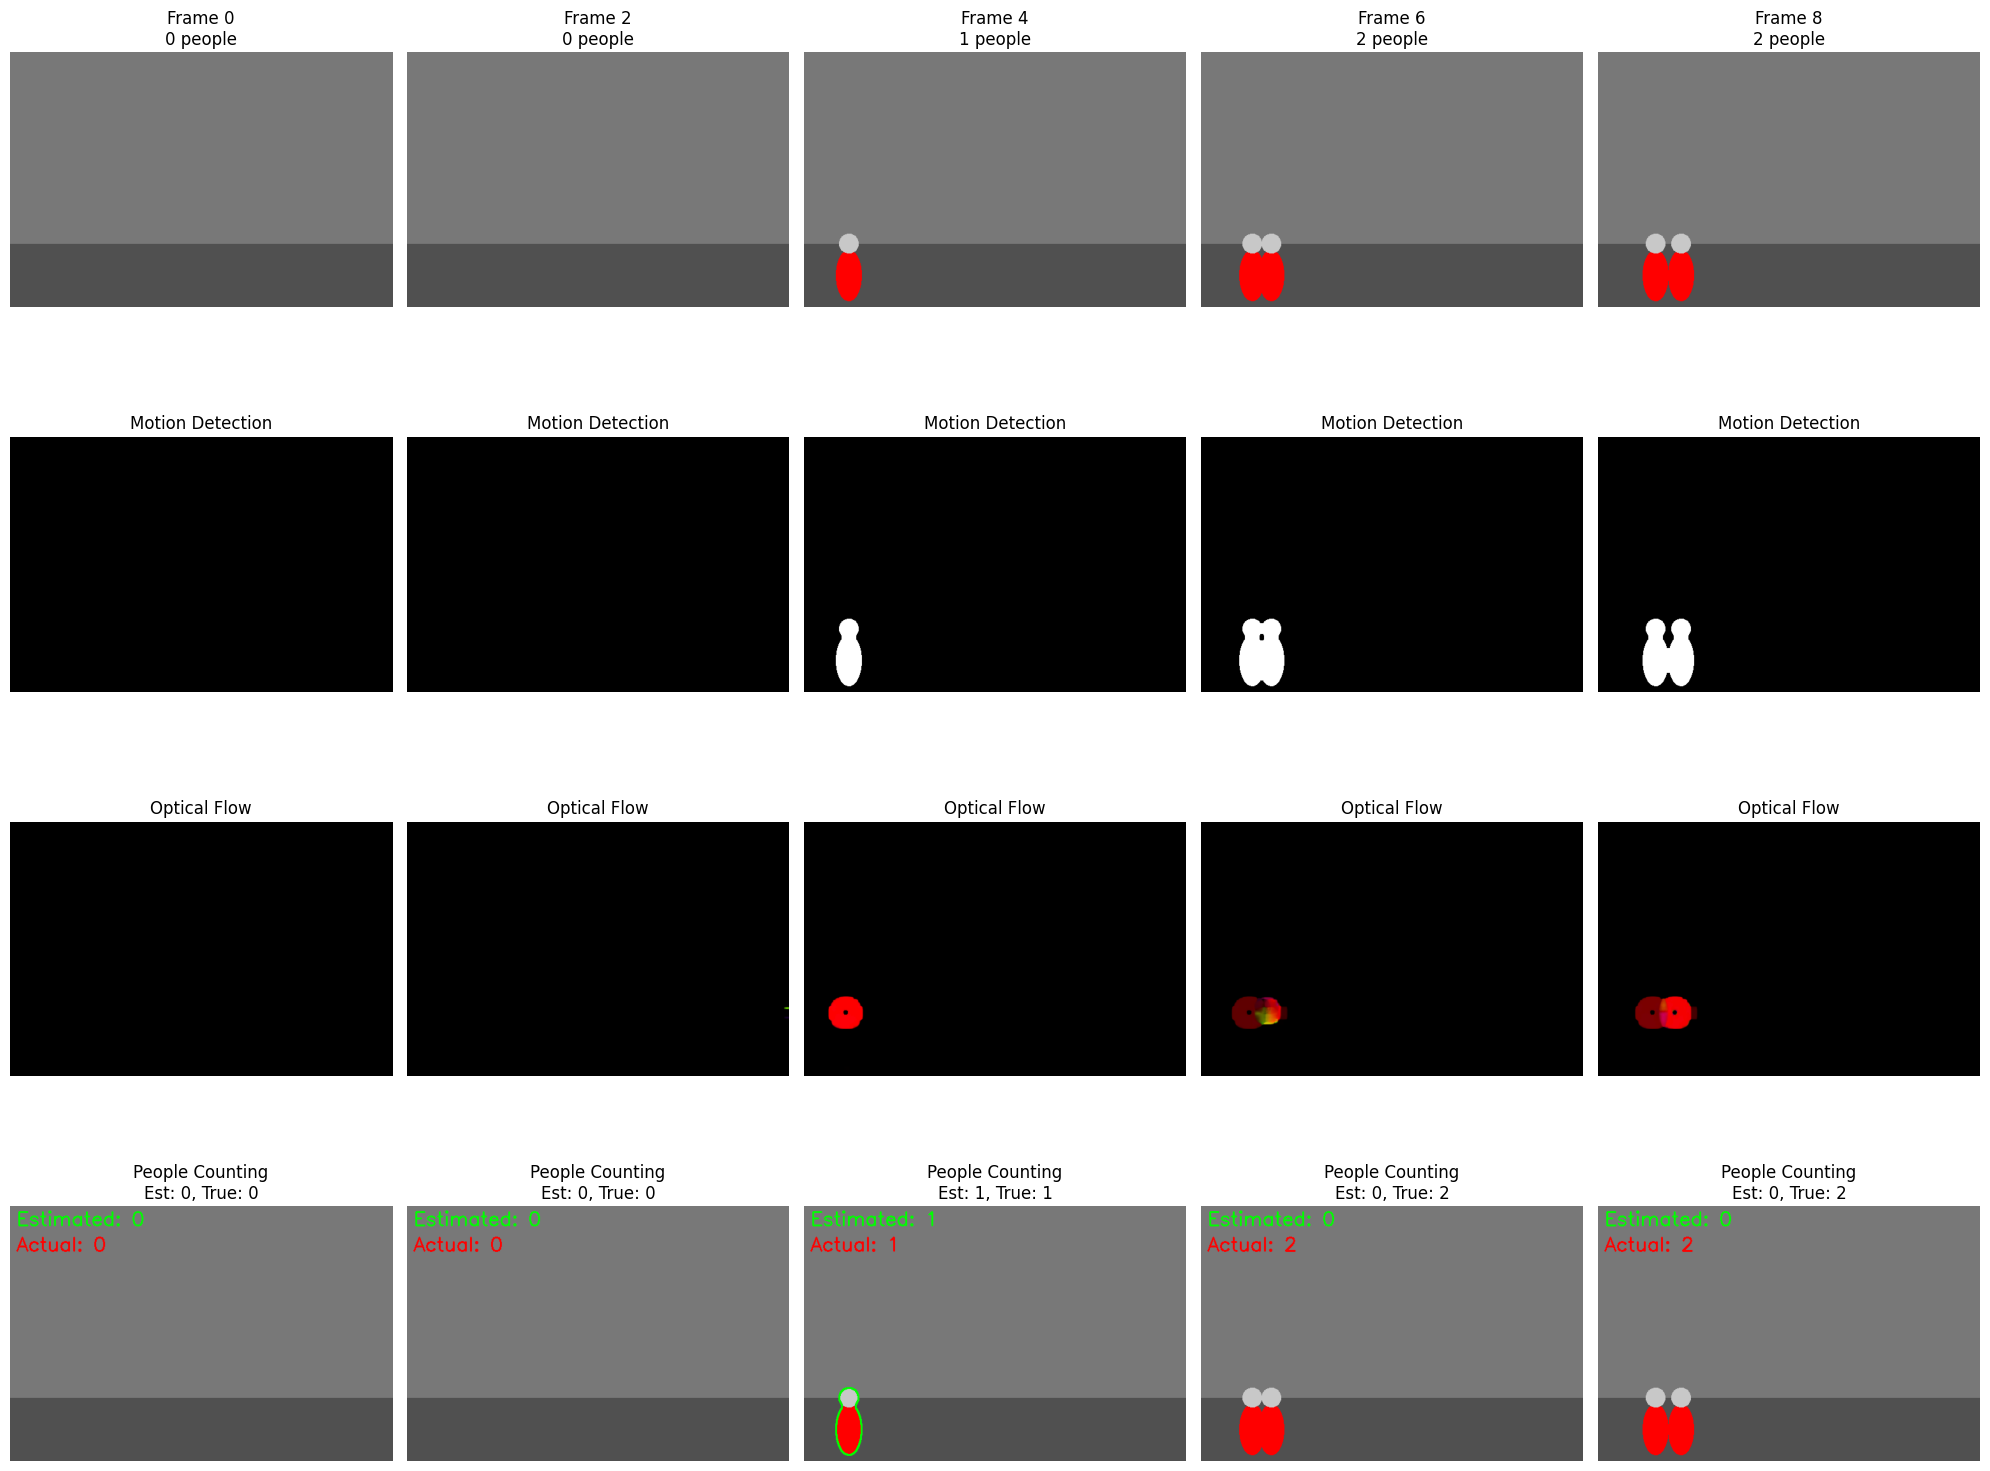

SURVEILLANCE SYSTEM PERFORMANCE ANALYSIS
Counting Accuracy: 0.600 (60.0%)
Mean Absolute Error: 0.90 people per frame
Total People Detected: 3
Total Actual People: 12

SIMPLE TRACKING SIMULATION
------------------------------
Frame 0: 0 people detected
Frame 1: 0 people detected
Frame 2: 0 people detected
Frame 3: 1 people detected
Frame 4: 1 people detected
Frame 5: 1 people detected
Frame 6: 0 people detected
Frame 7: 0 people detected
Frame 8: 0 people detected
Frame 9: 0 people detected


/tmp/ipykernel_1703/2680762105.py:234: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


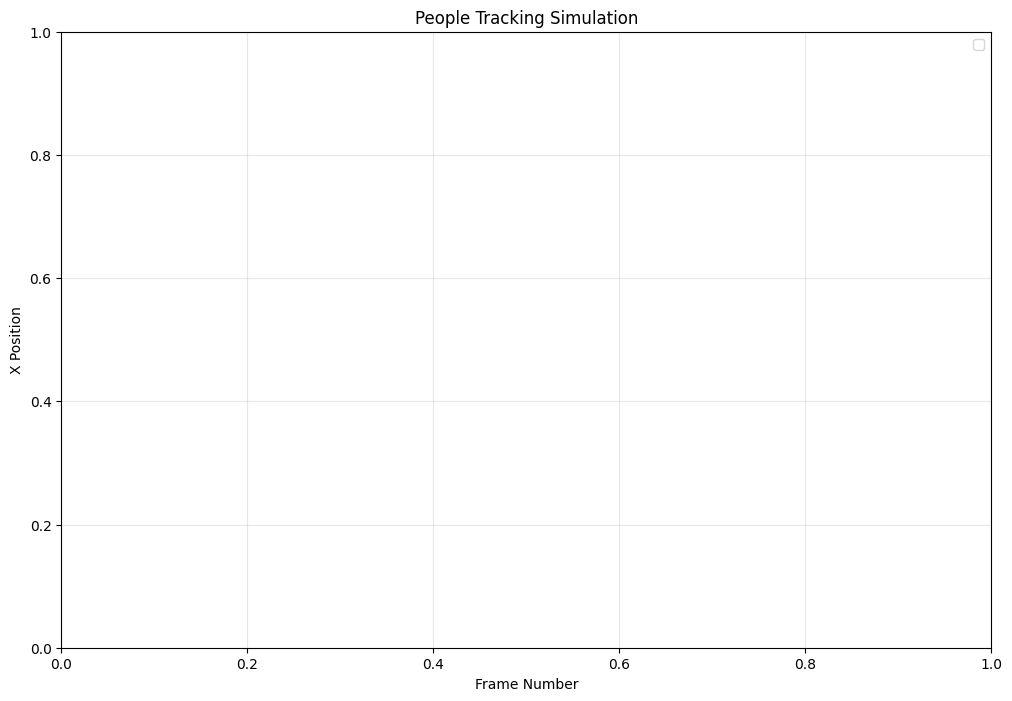

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from PIL import Image

def praktikum_7_4():
    print("SURVEILLANCE SYSTEMS: PEOPLE COUNTING AND TRACKING")
    print("=" * 55)

    # Simulate surveillance video frames
    def generate_surveillance_frames(num_frames=10):
        frames = []
        height, width = 400, 600

        # Create background (static scene)
        background = np.ones((height, width, 3), dtype=np.uint8) * 100
        # Add some static elements (walls, floor pattern)
        cv2.rectangle(background, (0, 300), (width, height), (80, 80, 80), -1)  # Floor
        cv2.rectangle(background, (0, 0), (width, 300), (120, 120, 120), -1)    # Wall

        for frame_idx in range(num_frames):
            frame = background.copy()

            # Add moving people (ellipses that move across the frame)
            num_people = min(3, frame_idx // 3)  # Gradually increase people count

            people_positions = []
            for i in range(num_people):
                # Each person moves at different speeds
                speed = (i + 1) * 5
                x_pos = 50 + (frame_idx * speed) % (width - 100)
                y_pos = 350  # Fixed height (walking on floor)

                # Draw person as ellipse
                cv2.ellipse(frame, (x_pos, y_pos), (20, 40), 0, 0, 360,
                           (0, 0, 255), -1)  # Red ellipse for person
                cv2.ellipse(frame, (x_pos, y_pos - 50), (15, 15), 0, 0, 360,
                           (200, 200, 200), -1)  # Head

                people_positions.append((x_pos, y_pos))

            frames.append((frame, people_positions))

        return frames

    # People detection and counting algorithms
    def background_subtraction(frames):
        """Simple background subtraction for motion detection"""
        # Use first frame as background
        background = frames[0][0].astype(np.float32)

        results = []
        for frame, _ in frames:
            current_frame = frame.astype(np.float32)

            # Compute absolute difference
            diff = cv2.absdiff(current_frame, background)
            diff_gray = cv2.cvtColor(diff.astype(np.uint8), cv2.COLOR_BGR2GRAY)

            # Threshold to get motion mask
            _, motion_mask = cv2.threshold(diff_gray, 30, 255, cv2.THRESH_BINARY)

            # Morphological operations to clean up
            kernel = np.ones((5, 5), np.uint8)
            motion_mask = cv2.morphologyEx(motion_mask, cv2.MORPH_OPEN, kernel)
            motion_mask = cv2.morphologyEx(motion_mask, cv2.MORPH_CLOSE, kernel)

            results.append(motion_mask)

        return results

    def optical_flow_detection(frames):
        """Optical flow based motion detection"""
        results = []
        prev_gray = None

        for i, (frame, _) in enumerate(frames):
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

            if prev_gray is not None:
                # Calculate optical flow using Farneback method
                flow = cv2.calcOpticalFlowFarneback(prev_gray, gray, None,
                                                   0.5, 3, 15, 3, 5, 1.2, 0)

                # Convert flow to magnitude and angle
                magnitude, angle = cv2.cartToPolar(flow[..., 0], flow[..., 1])

                # Create HSV representation for visualization
                hsv = np.zeros_like(frame)
                hsv[..., 0] = angle * 180 / np.pi / 2  # Hue based on direction
                hsv[..., 1] = 255  # Full saturation
                hsv[..., 2] = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)  # Value based on magnitude

                flow_rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
                results.append(flow_rgb)
            else:
                results.append(np.zeros_like(frame))

            prev_gray = gray

        return results

    def blob_detection_people_counting(motion_masks, frames):
        """Count people using blob detection on motion masks"""
        people_counts = []
        detailed_results = []

        for i, (motion_mask, (frame, true_positions)) in enumerate(zip(motion_masks, frames)):
            # Find contours in motion mask
            contours, _ = cv2.findContours(motion_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            # Filter contours by area (people-sized blobs)
            min_area = 500
            max_area = 5000
            people_contours = []

            for contour in contours:
                area = cv2.contourArea(contour)
                if min_area < area < max_area:
                    people_contours.append(contour)

            # Estimate people count
            estimated_count = len(people_contours)
            true_count = len(true_positions)

            # Create result visualization
            result_frame = frame.copy()
            cv2.drawContours(result_frame, people_contours, -1, (0, 255, 0), 2)

            # Add count information
            cv2.putText(result_frame, f'Estimated: {estimated_count}', (10, 30),
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
            cv2.putText(result_frame, f'Actual: {true_count}', (10, 70),
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

            people_counts.append((estimated_count, true_count))
            detailed_results.append(result_frame)

        return people_counts, detailed_results

    # Generate surveillance footage
    frames = generate_surveillance_frames(10)

    # Apply different detection methods
    motion_masks = background_subtraction(frames)
    optical_flows = optical_flow_detection(frames)
    people_counts, counting_results = blob_detection_people_counting(motion_masks, frames)

    # Visualize results
    fig, axes = plt.subplots(4, 5, figsize=(20, 16))

    for i in range(5):  # Show first 5 frames
        if i * 2 < len(frames):
            # Original frame
            axes[0, i].imshow(cv2.cvtColor(frames[i*2][0], cv2.COLOR_BGR2RGB))
            axes[0, i].set_title(f'Frame {i*2}\n{len(frames[i*2][1])} people')
            axes[0, i].axis('off')

            # Motion mask
            axes[1, i].imshow(motion_masks[i*2], cmap='gray')
            axes[1, i].set_title('Motion Detection')
            axes[1, i].axis('off')

            # Optical flow
            axes[2, i].imshow(cv2.cvtColor(optical_flows[i*2], cv2.COLOR_BGR2RGB))
            axes[2, i].set_title('Optical Flow')
            axes[2, i].axis('off')

            # People counting result
            axes[3, i].imshow(cv2.cvtColor(counting_results[i*2], cv2.COLOR_BGR2RGB))
            est_count, true_count = people_counts[i*2]
            axes[3, i].set_title(f'People Counting\nEst: {est_count}, True: {true_count}')
            axes[3, i].axis('off')

    plt.tight_layout()
    plt.show()

    # Performance analysis
    print("SURVEILLANCE SYSTEM PERFORMANCE ANALYSIS")
    print("=" * 50)

    estimated_counts = [est for est, true in people_counts]
    true_counts = [true for est, true in people_counts]

    accuracy = np.mean(np.array(estimated_counts) == np.array(true_counts))
    mae = np.mean(np.abs(np.array(estimated_counts) - np.array(true_counts)))

    print(f"Counting Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")
    print(f"Mean Absolute Error: {mae:.2f} people per frame")
    print(f"Total People Detected: {sum(estimated_counts)}")
    print(f"Total Actual People: {sum(true_counts)}")

    # Tracking simulation
    print("\nSIMPLE TRACKING SIMULATION")
    print("-" * 30)

    # Simulate tracking by connecting detections across frames
    tracks = {}
    next_track_id = 0

    for frame_idx, (est_count, true_count) in enumerate(people_counts):
        # Simulate track updates
        current_detections = est_count
        print(f"Frame {frame_idx}: {current_detections} people detected")

        # Simple tracking logic (for demonstration)
        if frame_idx == 0:
            # Initialize tracks
            for i in range(current_detections):
                tracks[next_track_id] = {'age': 0, 'positions': [(frame_idx, i*50 + 100)]}
                next_track_id += 1
        else:
            # Update existing tracks or create new ones
            for track_id in list(tracks.keys()):
                tracks[track_id]['age'] += 1
                # Simulate position update
                last_pos = tracks[track_id]['positions'][-1][1]
                new_pos = last_pos + np.random.randint(-10, 10)
                tracks[track_id]['positions'].append((frame_idx, new_pos))

    # Display tracking results
    plt.figure(figsize=(12, 8))
    for track_id, track_info in tracks.items():
        positions = track_info['positions']
        frames = [pos[0] for pos in positions]
        x_positions = [pos[1] for pos in positions]
        plt.plot(frames, x_positions, marker='o', label=f'Track {track_id}')

    plt.xlabel('Frame Number')
    plt.ylabel('X Position')
    plt.title('People Tracking Simulation')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return people_counts, tracks

people_counts, tracking_data = praktikum_7_4()